In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('../datasets/Student_Performance.csv')

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
x = df.drop(columns = 'Performance Index')
y = df['Performance Index']

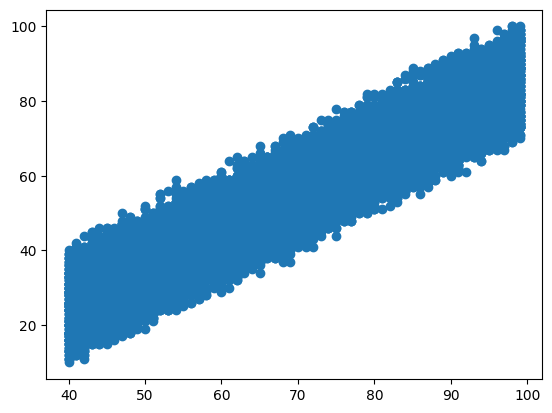

In [24]:
plt.scatter(x['Previous Scores'],y)

In [6]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

C:\Users\shankar paikira\AppData\Local\Temp\ipykernel_3184\3959530517.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = x.select_dtypes(include='object').columns


<Axes: >

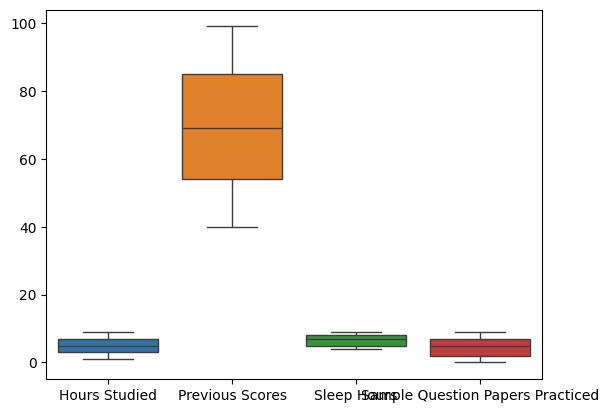

In [7]:
sns.boxplot(x[num_cols])

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [9]:
scaling = MinMaxScaler()
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [10]:
df.select_dtypes(include='number').corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [11]:
xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [12]:
# label_encoder = LabelEncoder()
# '''
# xtrain[obj_cols] = label_encoder.fit_transform(xtrain[obj_cols])

# ValueError: Columns must be same length as key
# '''

# xtrain['Extracurricular Activities'] = label_encoder.fit_transform(xtrain['Extracurricular Activities'])
# xtrain

In [13]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values = onehot_encoder.fit_transform(xtrain[obj_cols])
cols = onehot_encoder.get_feature_names_out()

cols

array(['Extracurricular Activities_No', 'Extracurricular Activities_Yes'],
      dtype=object)

In [14]:
xtrain[cols] = values
xtrain.drop(columns = ['Extracurricular Activities'],inplace= True)
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [15]:
xtest[num_cols] = scaling.transform(xtest[num_cols])
xtest_values = onehot_encoder.transform(xtest[obj_cols])
xtest[cols] = xtest_values
xtest.drop(columns = 'Extracurricular Activities', inplace=True)
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...
6412,0.125,0.508475,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,0.6,0.555556,1.0,0.0


In [16]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# Evaluation part

model.score(xtrain,ytrain)

0.9886898790682355

In [18]:
model.score(xtest,ytest)

0.9889832909573145